# Obtaining the Graphs for ASTROMoRF Journal Paper.

This script obtains the graphs for the pickle files run on an HPC


## Load Necessary Modules

In [ ]:
import sys
import pathlib
from pathlib import Path
import os
import logging
import types


import pickle
import numpy as np
import random
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Take the current directory, find the parent, and add it to the system path
sys.path.append(str(Path.cwd().parent))

from simopt.experiment_base import (
    ProblemsSolvers,
    read_experiment_results,
    PlotType, 
    plot_solvability_profiles, 
    plot_budget_history, 
    plot_fn_estimates, 
    plot_progress_curves
)
from demo.plot_datafarming import plot_datafarming_results, create_results_dataframe

#Get the experiments Results directory where all the ProblemsSolvers pickles will be stored
experiment_dir = Path.cwd() / "experiments" / "Journal_Test_Results"
if not experiment_dir.exists():
    os.makedirs(experiment_dir)

local_pathlib_module = types.ModuleType("pathlib._local")
setattr(local_pathlib_module, "PosixPath", pathlib.PosixPath)
setattr(local_pathlib_module, "WindowsPath", pathlib.WindowsPath)
sys.modules["pathlib._local"] = local_pathlib_module

### EXPERIMENT 1: Comparison of Solvers

In this experiment we compare ASTROMoRF against other state of the art solvers on a testbed of SO problems. We get plots for the solvability profiles as well as change in function estimates and budget over the run for each solver.


In [2]:


path_comparison = "/Users/benjaminrees/Desktop/Journal_Pickles/comparison_18_02_26/"

#find all the pickles in the directory that contain "POSTREPS" in the filename - get a list of their file paths
pickles = [f for f in os.listdir(path_comparison) if f.endswith('.pickle') and "POSTREPS" in f]

print(f"Found {len(pickles)} pickles")
[print(f) for f in pickles]

#now load. the pickle files as ProblemsSolvers objects

ps_list = []
experiments_comparison = []
for pkl in pickles:
    #load in experiments but if the solver is RNDSR, skip it
    experiment = read_experiment_results(os.path.join(path_comparison, pkl))
    # if experiment.solver.name == "RANDOM SEARCH":
    #     print(f"Skipping RNDSR experiment: {pkl}")
    #     continue
    experiments_comparison.append(experiment) 

print(f"Loaded {len(experiments_comparison)} experiments after filtering out RNDSR")

#print the number of macroreps for each experiment
for exp in experiments_comparison:
    print(f"Experiment: {exp.solver.name} on {exp.problem.name} has {exp.n_macroreps} macroreps")

    


Found 30 pickles
ADAM_ON_PARAMESTI-1_CRN(False)_POSTREPS.pickle
STRONG_ON_SAN-1_CRN(False)_POSTREPS.pickle
ADAM_ON_DYNAMNEWS-1_CRN(False)_POSTREPS.pickle
ASTROMORF_ON_ROSENBROCK-1_CRN(False)_POSTREPS.pickle
NELDMD_ON_NETWORK-1_CRN(False)_POSTREPS.pickle
ASTRODF_ON_NETWORK-1_CRN(False)_POSTREPS.pickle
RNDSRCH_ON_DYNAMNEWS-1_CRN(False)_POSTREPS.pickle
RNDSRCH_ON_PARAMESTI-1_CRN(False)_POSTREPS.pickle
ADAM_ON_SAN-1_CRN(False)_POSTREPS.pickle
ASTROMORF_ON_SAN-1_CRN(False)_POSTREPS.pickle
STRONG_ON_ROSENBROCK-1_CRN(False)_POSTREPS.pickle
RNDSRCH_ON_NETWORK-1_CRN(False)_POSTREPS.pickle
NELDMD_ON_SAN-1_CRN(False)_POSTREPS.pickle
ASTRODF_ON_PARAMESTI-1_CRN(False)_POSTREPS.pickle
ASTRODF_ON_DYNAMNEWS-1_CRN(False)_POSTREPS.pickle
STRONG_ON_PARAMESTI-1_CRN(False)_POSTREPS.pickle
STRONG_ON_DYNAMNEWS-1_CRN(False)_POSTREPS.pickle
ASTRODF_ON_ROSENBROCK-1_CRN(False)_POSTREPS.pickle
ADAM_ON_ROSENBROCK-1_CRN(False)_POSTREPS.pickle
RNDSRCH_ON_SAN-1_CRN(False)_POSTREPS.pickle
ASTROMORF_ON_DYNAMNEWS-1_CRN(

In [3]:
#Create an instance of ProblemsSolvers that contains all the experiments

#first need to make experiments a list of list of ProblemSolver objects where each inner list has the same solver 

experiments_sorted = {}
for exp in experiments_comparison:
    key = exp.solver.name
    if key not in experiments_sorted:
        experiments_sorted[key] = []
    experiments_sorted[key].append(exp)

# pretty print each solver and problem pair in the experiments_sorted
for solver_name, exps in experiments_sorted.items():
    for exp in exps:
        print(f"Solver: {solver_name}, Problem: {exp.problem.name}")
    print("\n")

#now turn experiments_sorted into a list of lists where each value of the dict is a sublist 
ps_list = list(experiments_sorted.values())

file_name_path = experiment_dir / "comparison_experiment_results.pickle"
comparison_experiment = ProblemsSolvers(experiments=ps_list, file_name_path=file_name_path)

print(f'Comparison ProblemsSolvers has file path: {comparison_experiment.file_name_path}')


Solver: ADAM, Problem: PARAMESTI-1
Solver: ADAM, Problem: DYNAMNEWS-1
Solver: ADAM, Problem: SAN-1
Solver: ADAM, Problem: ROSENBROCK-1
Solver: ADAM, Problem: NETWORK-1


Solver: STRONG, Problem: SAN-1
Solver: STRONG, Problem: ROSENBROCK-1
Solver: STRONG, Problem: PARAMESTI-1
Solver: STRONG, Problem: DYNAMNEWS-1
Solver: STRONG, Problem: NETWORK-1


Solver: ASTROMoRF, Problem: ROSENBROCK-1
Solver: ASTROMoRF, Problem: SAN-1
Solver: ASTROMoRF, Problem: DYNAMNEWS-1
Solver: ASTROMoRF, Problem: PARAMESTI-1
Solver: ASTROMoRF, Problem: NETWORK-1


Solver: NELDER MEAD, Problem: NETWORK-1
Solver: NELDER MEAD, Problem: SAN-1
Solver: NELDER MEAD, Problem: PARAMESTI-1
Solver: NELDER MEAD, Problem: DYNAMNEWS-1
Solver: NELDER MEAD, Problem: ROSENBROCK-1


Solver: ASTRO-DF, Problem: NETWORK-1
Solver: ASTRO-DF, Problem: PARAMESTI-1
Solver: ASTRO-DF, Problem: DYNAMNEWS-1
Solver: ASTRO-DF, Problem: ROSENBROCK-1
Solver: ASTRO-DF, Problem: SAN-1


Solver: RANDOM SEARCH, Problem: DYNAMNEWS-1
Solver: RANDOM S

In [4]:
#get number of postreps from first experiment in the list
num_postreps_init_opt = experiments_comparison[0].n_postreps

# Configure logging so we see which pair is currently running
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
print("Logging set to INFO. You will see per-pair progress as they start/finish.")

print("Post-normalizing results.")

# Find an optimal solution x* for normalization.
comparison_experiment.post_normalize(n_postreps_init_opt=num_postreps_init_opt)

2026-02-18 17:31:24,819 | INFO | Postnormalizing on Problem PARAMESTI-1.
2026-02-18 17:31:24,820 | INFO | Finding f(x*) using using coded x*.
2026-02-18 17:31:24,845 | INFO | Finding f(x*) using using coded x*.
2026-02-18 17:31:24,870 | INFO | Finding f(x*) using using coded x*.
2026-02-18 17:31:24,894 | INFO | Finding f(x*) using using coded x*.
2026-02-18 17:31:24,922 | INFO | Finding f(x*) using using coded x*.
2026-02-18 17:31:24,946 | INFO | Finding f(x*) using using coded x*.
2026-02-18 17:31:24,971 | INFO | Postnormalizing on Problem DYNAMNEWS-1.


Logging set to INFO. You will see per-pair progress as they start/finish.
Post-normalizing results.


2026-02-18 17:31:26,622 | INFO | Global proxy x* computed for problem DYNAMNEWS-1.
2026-02-18 17:31:26,622 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-02-18 17:31:28,255 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-02-18 17:31:29,922 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-02-18 17:31:31,635 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-02-18 17:31:33,316 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-02-18 17:31:34,945 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-02-18 17:31:36,562 | INFO | Postnormalizing on Problem SAN-1.
2026-02-18 17:31:36,680 | INFO | Global proxy x* computed for problem SAN-1.
2026-02-18 17:31:36,680 | INFO | Finding f(x*) using using global best postreplicated solution as pro

In [5]:
# Produce basic plots.
import matplotlib.pyplot as plt
from IPython.display import Image, display

from simopt.experiment_base import PlotType, plot_solvability_profiles, plot_budget_history, plot_fn_estimates, plot_progress_curves

SAVE_PATH: Path | None = None 

print("Plotting results...")

ps_same_problem_dict = {}
# take the experiments of comparison_experiment and create a list of lists from ps_same_problem_list where each sublist contains all solvers for a given problem
experiments_flattened = [ps for solver_experiments in comparison_experiment.experiments for ps in solver_experiments]
for exp in experiments_flattened:
    if exp.problem.name not in ps_same_problem_dict:
        ps_same_problem_dict[exp.problem.name] = []
    ps_same_problem_dict[exp.problem.name].append(exp)

#turn the items of ps_same_problem_dict into a list of lists
experiments_same_problem = []
for problem_name, ps_list in ps_same_problem_dict.items():
    experiments_same_problem.append(ps_list)


def _print_path_and_display(plot_paths: list[Path]) -> Path:
    for plot_path in plot_paths:
        print(f"Plot saved to {plot_path!s}")
        display(Image(filename=str(plot_path)))
    return plot_paths[-1].parent

# comparison_experiment.experiments is structured as experiments[solver_idx][problem_idx]
# To plot all solvers for each problem, we need to transpose the structure
n_solvers = len(comparison_experiment.experiments)
n_problems = len(comparison_experiment.experiments[0]) if n_solvers > 0 else 0

Plotting results...


Plot saved to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-02-18_17-31-24/plots/Performance of State-of-the-Art Solvers against ASTROMoRF.png


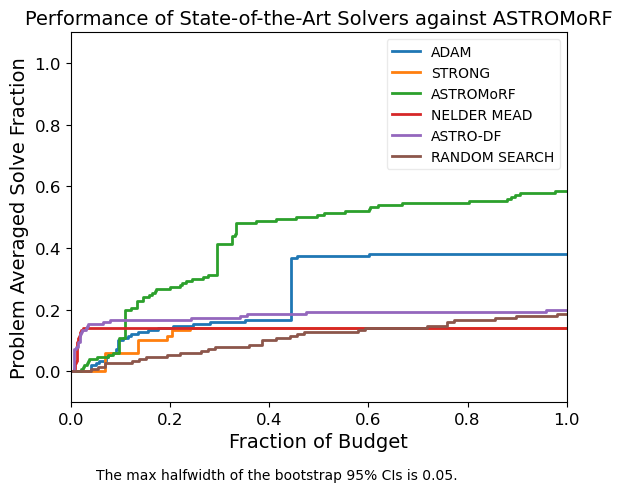

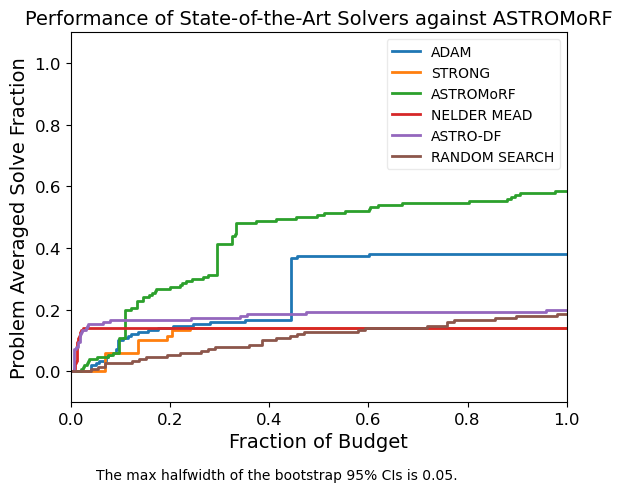

In [6]:
SAVE_PATH = _print_path_and_display(
    plot_solvability_profiles(
        experiments=comparison_experiment.experiments, 
        plot_type=PlotType.CDF_SOLVABILITY,
        plot_title="Performance of State-of-the-Art Solvers against ASTROMoRF",
        legend_loc="upper right",
        plot_conf_ints=False
    )
)

Plot saved to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-02-18_17-31-24/plots/Progress Curves for PARAMESTI-1.png


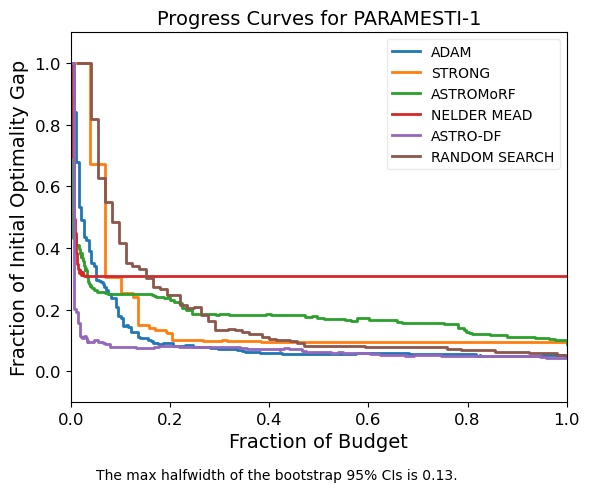

Plot saved to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-02-18_17-31-24/plots/Progress Curves for DYNAMNEWS-1.png


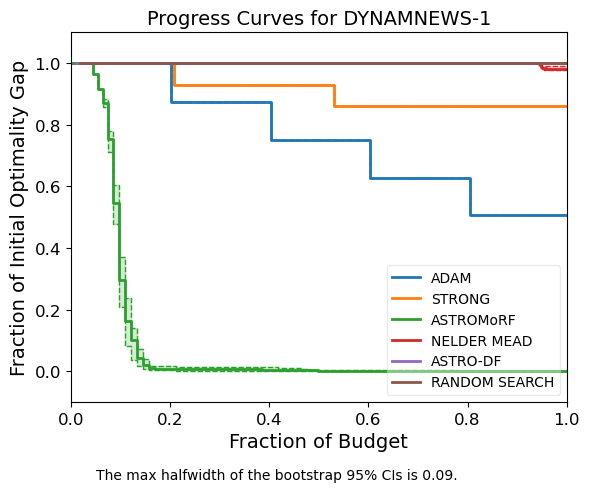

Plot saved to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-02-18_17-31-24/plots/Progress Curves for SAN-1.png


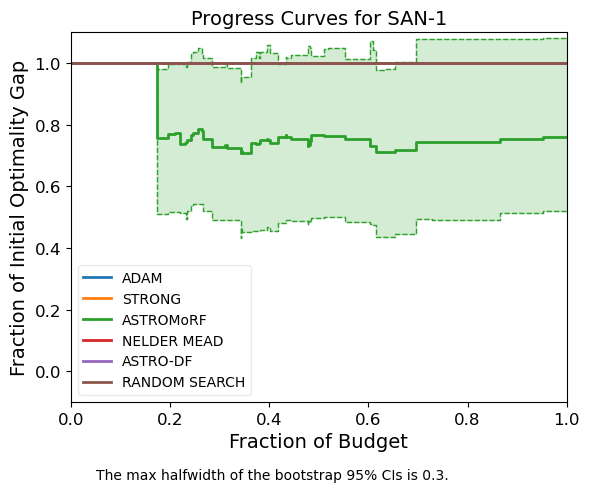

Plot saved to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-02-18_17-31-24/plots/Progress Curves for ROSENBROCK-1.png


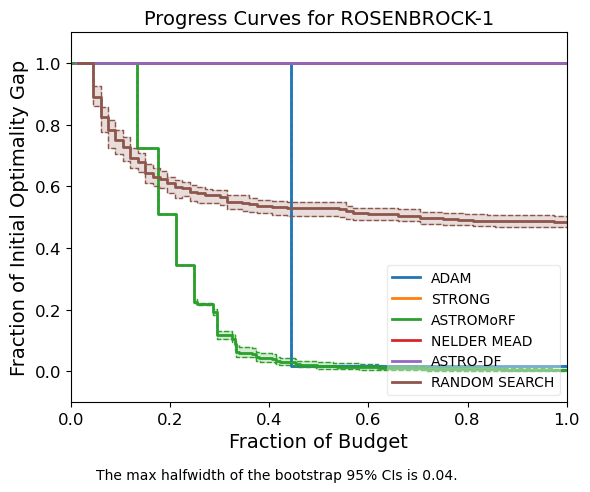

Plot saved to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-02-18_17-31-24/plots/Progress Curves for NETWORK-1.png


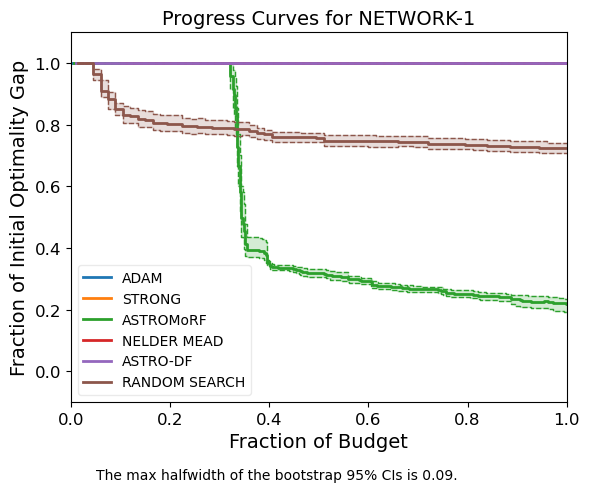

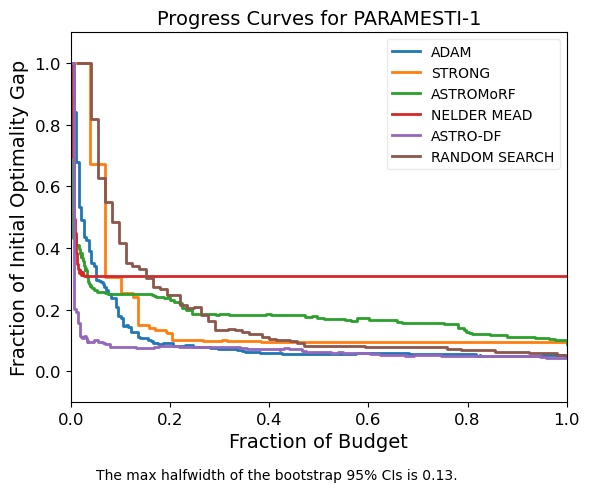

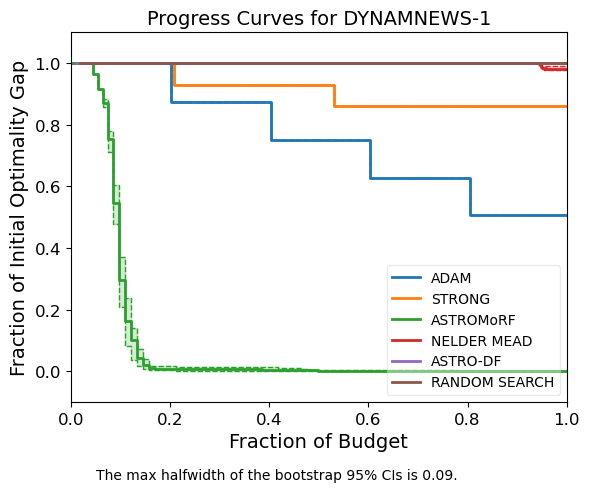

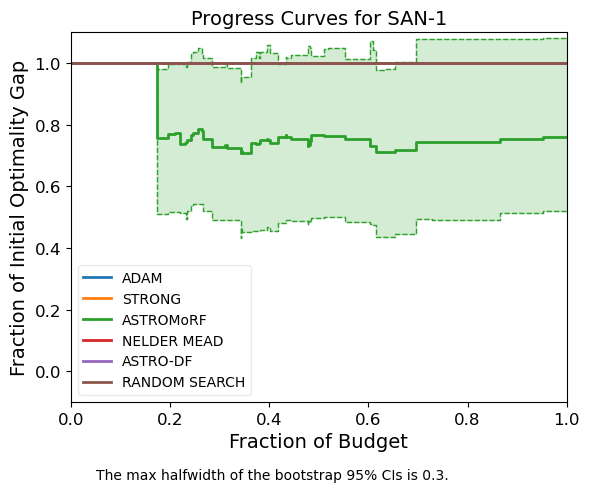

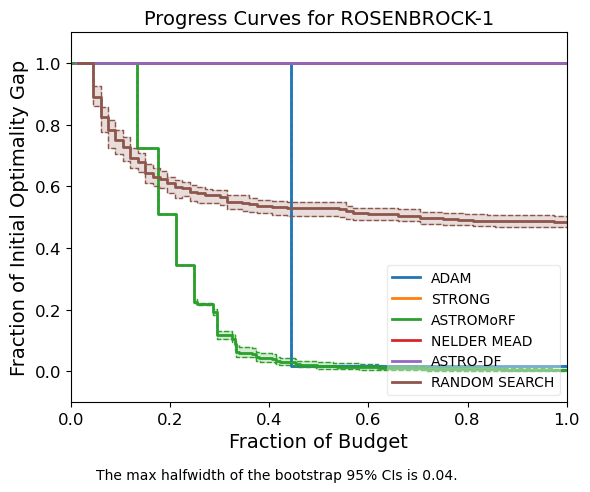

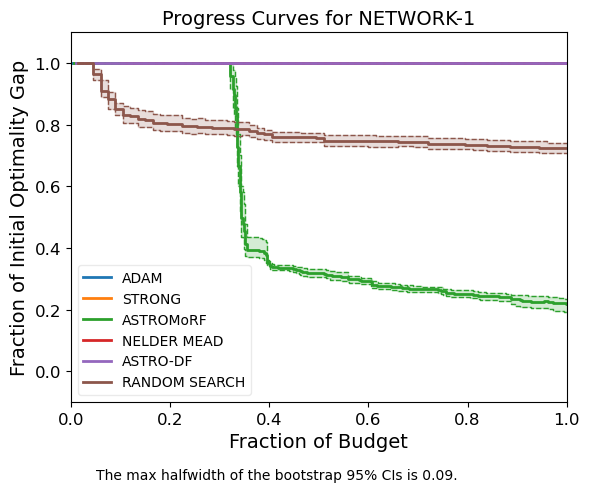

In [7]:
legend_locs = [] 
for idx in range(len(experiments_same_problem)) : 
    if experiments_same_problem[idx][0].problem.name == "PARAMESTI-1":
        legend_locs.append("upper right")
    elif experiments_same_problem[idx][0].problem.name in ["DYNAMNEWS-1", "ROSENBROCK-1"]:
        legend_locs.append("lower right")
    else :
        legend_locs.append("lower left")

for experiments, legend_loc in zip(experiments_same_problem, legend_locs):
    if experiments[0].problem.name == "PARAMESTI-1":
        _print_path_and_display(
            plot_progress_curves(
                experiments=experiments, 
                plot_type=PlotType.MEAN, 
                solver_set_name="Comparison of Solvers", 
                plot_title=f"Progress Curves for {experiments[0].problem.name}",
                normalize=True,
                plot_conf_ints=False,
                allow_xstar_mismatch=True,
                legend_loc = legend_loc
            )
        )
    else :
        _print_path_and_display(
            plot_progress_curves(
                experiments=experiments, 
                plot_type=PlotType.MEAN, 
                solver_set_name="Comparison of Solvers", 
                plot_title=f"Progress Curves for {experiments[0].problem.name}",
                normalize=True,
                plot_conf_ints=True,
                allow_xstar_mismatch=True,
                legend_loc = legend_loc
            )
        )
        

In [26]:
#Get the iteration data for each experiment and print out the total budget entries for each experiment to check that we are not double counting the final entry at budget exhaustion
solver_budget_info = {}
for experiments in experiments_same_problem:
    for exp in experiments:
        for idx in range(len(exp.all_recommended_xs)):
                 if exp.solver.name not in solver_budget_info:
                     solver_budget_info[exp.solver.name] = []
                 log_msg = f"Experiment {idx} on {exp.problem.name}: \n \t budget entries: {exp.all_budget_history[idx]} \n \t iteration entries: {exp.all_iterations[idx]}"
                 solver_budget_info[exp.solver.name].append(log_msg)


for solver_name, logs in solver_budget_info.items():
    print(f"Solver: {solver_name}")
    for log in logs:
        print(log)
    print("\n\n")

Solver: ADAM
Experiment 0 on PARAMESTI-1: 
 	 budget entries: [5, 30, 55, 80, 105, 130, 155, 180, 205, 230, 255, 280, 305, 330, 355, 380, 405, 430, 455, 480, 505, 530, 555, 580, 605, 630, 655, 680, 705, 730, 755, 780, 805, 830, 855, 880, 905, 930, 955, 980, 1005, 1030, 1055, 1080, 1105, 1130, 1155, 1180, 1205, 1230, 1255, 1280, 1305, 1330, 1355, 1380, 1405, 1430, 1455, 1480, 1505, 1530, 1555, 1580, 1605, 1630, 1655, 1680, 1705, 1730, 1755, 1780, 1805, 1830, 1855, 1880, 1905, 1930, 1955, 1980, 2005, 2030, 2055, 2080, 2105, 2130, 2155, 2180, 2205, 2230, 2255, 2280, 2305, 2330, 2355, 2380, 2405, 2430, 2455, 2480, 2505, 2530, 2555, 2580, 2605, 2630, 2655, 2680, 2705, 2730, 2755, 2780, 2805, 2830, 2855, 2880, 2905, 2930, 2955, 2980, 3005, 3030, 3055, 3080, 3105, 3130, 3155, 3180, 3205, 3230, 3255, 3280, 3305, 3330, 3355, 3380, 3405, 3430, 3455, 3480, 3505, 3530, 3555, 3580, 3605, 3630, 3655, 3680, 3705, 3730, 3755, 3780, 3805, 3830, 3855, 3880, 3905, 3930, 3955, 3980, 4005, 4030, 4055, 4080

Plot saved to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-02-18_17-31-24/plots/Budget History for PARAMESTI-1.png


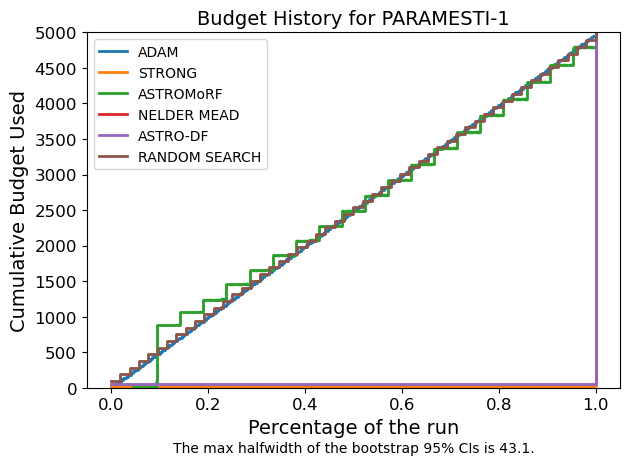

Plot saved to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-02-18_17-31-24/plots/Budget History for DYNAMNEWS-1.png


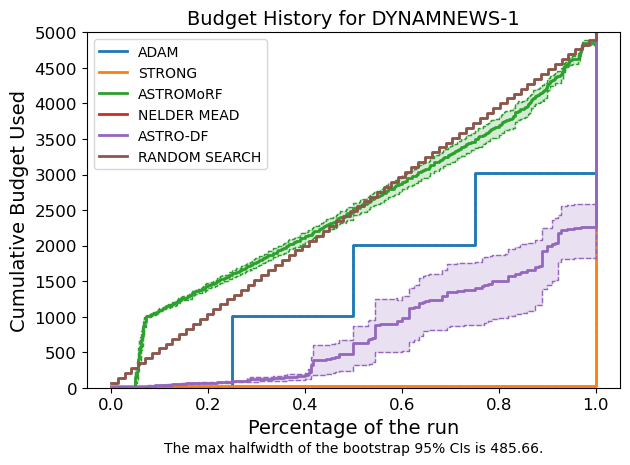

Plot saved to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-02-18_17-31-24/plots/Budget History for SAN-1.png


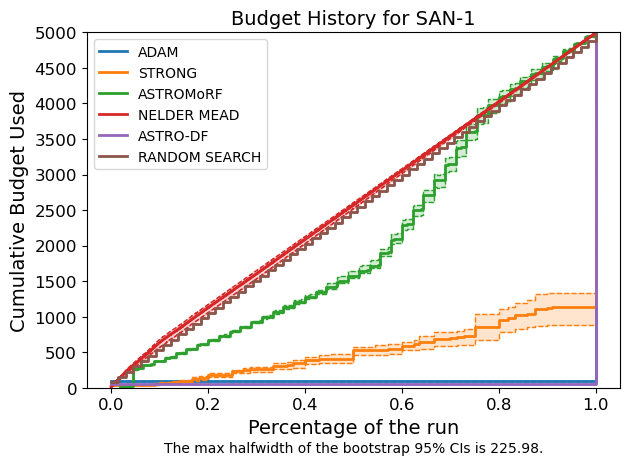

Plot saved to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-02-18_17-31-24/plots/Budget History for ROSENBROCK-1.png


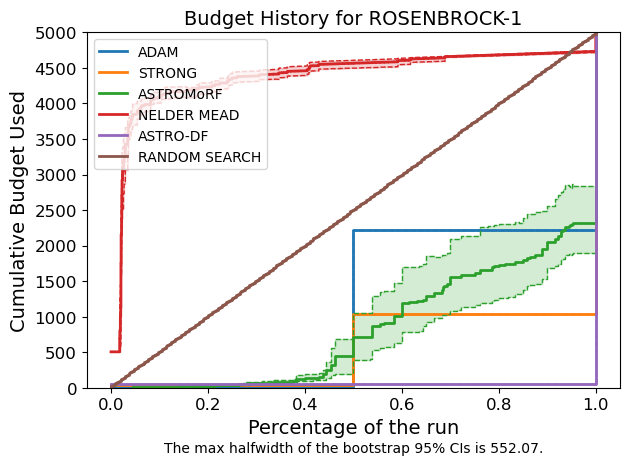

Plot saved to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-02-18_17-31-24/plots/Budget History for NETWORK-1.png


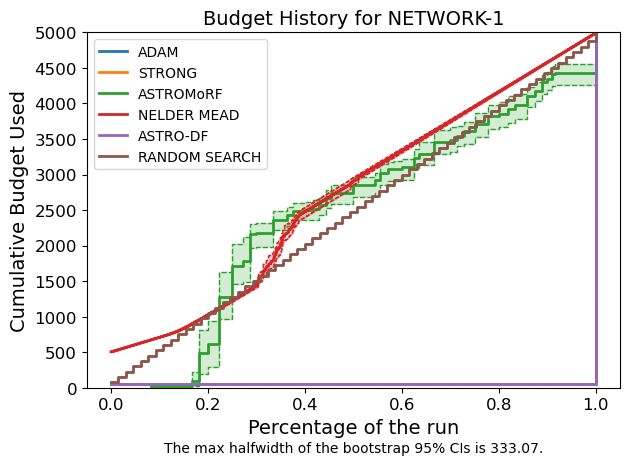

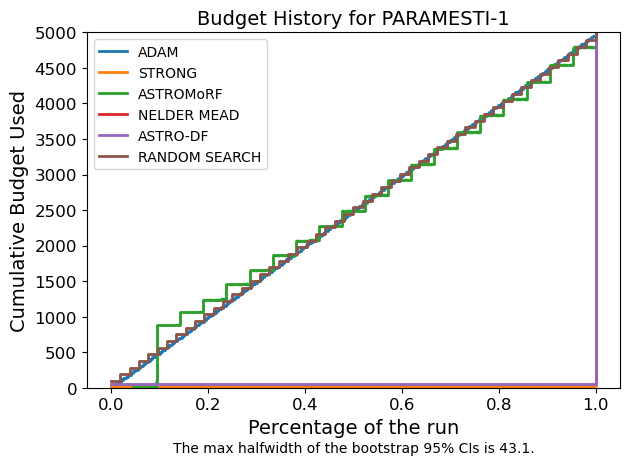

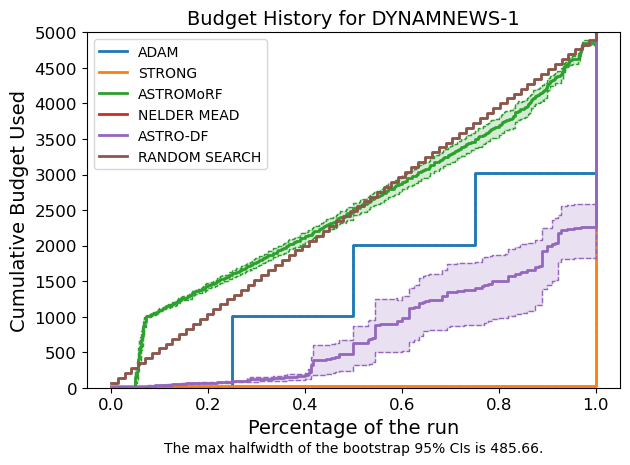

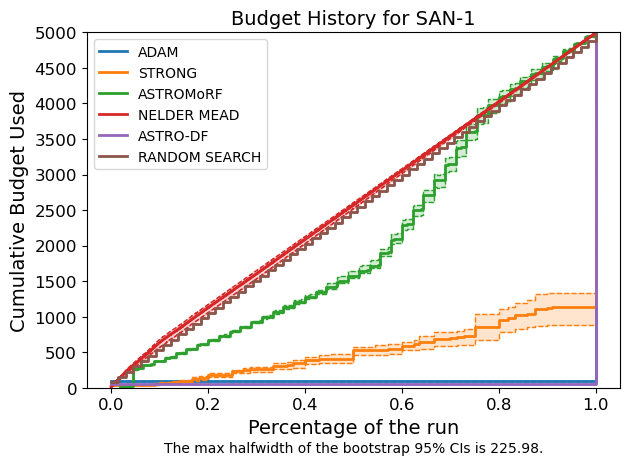

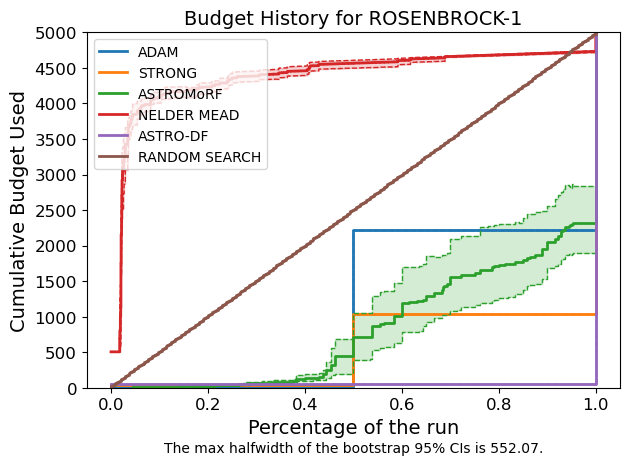

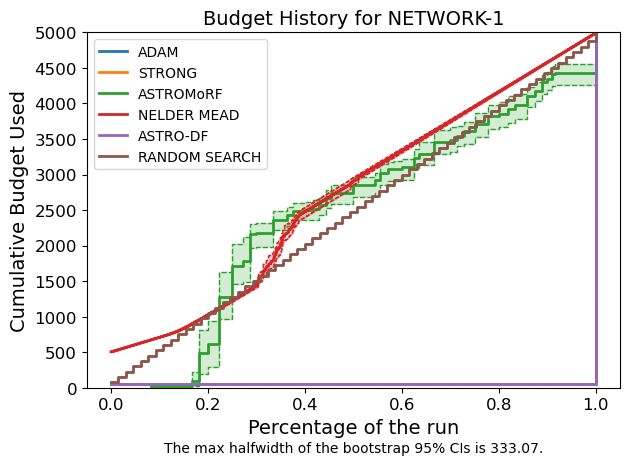

In [9]:
for prob_idx in range(n_problems):
    # Collect all solvers for this problem
    solvers_for_problem = [comparison_experiment.experiments[solver_idx][prob_idx] for solver_idx in range(n_solvers)]


    # # Maybe move the y-axis to being logarithmic 
    # _print_path_and_display(
    #     plot_fn_estimates(
    #         experiments=solvers_for_problem,
    #         plot_type=PlotType.FN_ESTIMATES_MEAN, 
    #         solver_set_name="Comparison of Solvers", 
    #         plot_title=f"Function Value Estimates for Problem {prob_idx+1}",
    #         normalize=True,
    #         y_normalize=True,
    #         all_in_one=True
    #     )
    # )
    _print_path_and_display(
        plot_budget_history(
            experiments=solvers_for_problem,
            plot_type=PlotType.BUDGET_HISTORY_MEAN, 
            plot_title=f"Budget History for {solvers_for_problem[0].problem.name}",
            solver_set_name="Comparison of Solvers", 
            normalize=True, 
            legend_loc="upper left"
        )
    )

In [ ]:
#get solver names from experiments_flattened and print out 
flattened_experiments = [ps for solver_experiments in comparison_experiment.experiments for ps in solver_experiments]

#Get the average number of iterations of ASTROMoRF vs ASTRO-DF for the problem SAN-1
astrodf_experiments = [ps for ps in flattened_experiments if ps.solver.name == "ASTRO-DF"]
astromorf_experiments = [ps for ps in flattened_experiments if ps.solver.name == "ASTROMoRF (CRN False)"]


def _terminal_iteration(ps) -> float | None:
    all_iterations = getattr(ps, "all_iterations", None)
    if not all_iterations:
        return None
    terminal_values: list[float] = []
    for seq in all_iterations:
        seq_arr = np.asarray(seq, dtype=float).reshape(-1)
        if seq_arr.size > 0 and np.isfinite(seq_arr[-1]):
            terminal_values.append(float(seq_arr[-1]))
    if not terminal_values:
        return None
    return float(np.mean(terminal_values))


def avg_iterations_prob(problem_name: str) -> tuple[float, float]:
    # reduce astrodf_experiments and astromorf_experiments to only those on problem_name
    astrodf_prob = [ps for ps in astrodf_experiments if ps.problem.name == problem_name]
    astromorf_prob = [ps for ps in astromorf_experiments if ps.problem.name == problem_name]

    astro_vals = [v for v in (_terminal_iteration(ps) for ps in astrodf_prob) if v is not None]
    astromorf_vals = [v for v in (_terminal_iteration(ps) for ps in astromorf_prob) if v is not None]

    avg_iterations_astrodf = float(np.mean(astro_vals)) if astro_vals else float("nan")
    avg_iterations_astromorf = float(np.mean(astromorf_vals)) if astromorf_vals else float("nan")

    return avg_iterations_astrodf, avg_iterations_astromorf

for problem_name in ["SAN-1", "ROSENBROCK-1", "DYNAMNEWS-1", "PARAMESTI-1", "NETWORK-1"]:
    avg_astrodf, avg_astromorf = avg_iterations_prob(problem_name)
    print(f"Problem: {problem_name}, Avg Iterations ASTRO-DF: {avg_astrodf:.2f}, Avg Iterations ASTROMoRF: {avg_astromorf:.2f}")

Problem: SAN-1, Avg Iterations ASTRO-DF: 0.00, Avg Iterations ASTROMoRF: nan
Problem: ROSENBROCK-1, Avg Iterations ASTRO-DF: 0.00, Avg Iterations ASTROMoRF: nan
Problem: DYNAMNEWS-1, Avg Iterations ASTRO-DF: 0.00, Avg Iterations ASTROMoRF: nan
Problem: PARAMESTI-1, Avg Iterations ASTRO-DF: 5.50, Avg Iterations ASTROMoRF: nan
Problem: NETWORK-1, Avg Iterations ASTRO-DF: 0.00, Avg Iterations ASTROMoRF: nan


### EXPERIMENT 2: Comparing the performance of ASTROMoRF ON CRN vs NON-CRN

In this experiment we compare the performance of ASTROMoRF under CRN on each problem vs Non-CRN

In [11]:
# Load CRN and non-CRN ASTROMoRF experiments robustly
path_crn = "/Users/benjaminrees/Desktop/Journal_Pickles/crn_18_02_26/"
pickles_crn = [f for f in os.listdir(path_crn) if f.endswith('.pickle') and "POSTREPS" in f]

import copy

# Collect ASTROMoRF experiments from comparison set (avoid string-in membership bug)
astromorf_experiments = []
for exp in experiments_comparison:
    if 'ASTROMoRF' in getattr(exp.solver, 'name', ''):
        astromorf_experiments.append(exp)


# Load CRN pickles and append
for pkl in pickles_crn:
    experiment = read_experiment_results(os.path.join(path_crn, pkl))
    astromorf_experiments.append(experiment)

# Ensure each solver has explicit `crn_across_solns` flag for grouping
for exp in astromorf_experiments:
    solver = exp.solver
    crn_flag = solver.factors.get('crn_across_solns', None)
    # Try common fallbacks if attribute missing
    if crn_flag is None:
        name = getattr(solver, 'name', '')
        if 'CRN True' in name or 'CRN_True' in name or 'CRNTrue' in name:
            crn_flag = True
        elif 'CRN False' in name or 'CRN_False' in name or 'CRNFalse' in name:
            crn_flag = False
        else:
            # default to False (non-CRN) when unknown
            crn_flag = False
    # attach the normalized attribute
    solver.crn_across_solns = bool(crn_flag)

In [12]:
# Create a ProblemsSolvers grouping keyed by the explicit crn_across_solns flag
experiments_sorted_crn = {}
for exp in astromorf_experiments:
    # Key by boolean CRN flag attached to the solver (ensure it's present)
    key = f"ASTROMoRF (CRN {exp.solver.factors.get('crn_across_solns', False)})"
    if key not in experiments_sorted_crn:
        experiments_sorted_crn[key] = []
    experiments_sorted_crn[key].append(exp)

# pretty print each solver and problem pair in the experiments_sorted
for solver_name, exps in experiments_sorted_crn.items():
    for exp in exps:
        exp.solver.name = solver_name # Ensure the solver's name reflects the CRN grouping for clarity in plots
        print(f"Solver: {solver_name}, Problem: {exp.problem.name}")
    print("\n")

# now turn experiments_sorted into a list of lists where each value of the dict is a sublist
ps_list_crn = list(experiments_sorted_crn.values())
crn_experiment = ProblemsSolvers(experiments=ps_list_crn, file_name_path="crn_experiment_results")

Solver: ASTROMoRF (CRN False), Problem: ROSENBROCK-1
Solver: ASTROMoRF (CRN False), Problem: SAN-1
Solver: ASTROMoRF (CRN False), Problem: DYNAMNEWS-1
Solver: ASTROMoRF (CRN False), Problem: PARAMESTI-1
Solver: ASTROMoRF (CRN False), Problem: NETWORK-1


Solver: ASTROMoRF (CRN True), Problem: DYNAMNEWS-1
Solver: ASTROMoRF (CRN True), Problem: ROSENBROCK-1
Solver: ASTROMoRF (CRN True), Problem: PARAMESTI-1
Solver: ASTROMoRF (CRN True), Problem: SAN-1
Solver: ASTROMoRF (CRN True), Problem: NETWORK-1




In [13]:
# Diagnostic: compare CRN True vs False using crn_across_solns attribute
import numpy as np
from collections import defaultdict
print('Running CRN grouping + budget diagnostics')
# flatten candidate experiments (prefer crn_experiment if created)
if 'crn_experiment' in globals():
    cands = [ps for solver_experiments in crn_experiment.experiments for ps in solver_experiments]
else:
    cands = astromorf_experiments

groups = defaultdict(list)
for e in cands:
    flag = getattr(e.solver, 'crn_across_solns', False)
    groups[bool(flag)].append(e)

for flag in [False, True]:
    exps = groups.get(flag, [])
    print(f'CRN={flag} count={len(exps)}')
    for e in exps[:5]:
        tb = [h[-1] for h in getattr(e, 'all_budget_history', []) if len(h) > 0]
        print(' ', getattr(e.solver, 'name', '???'), e.problem.name, 'mean_term_budget=', float(np.mean(tb)) if tb else None)

print('\nNETWORK-1 specific:')
for flag in [False, True]:
    net = [e for e in groups.get(flag, []) if getattr(e.problem, 'name', '') == 'NETWORK-1']
    print(f' CRN={flag} NETWORK-1 count={len(net)}')
    for e in net:
        print('  ', getattr(e.solver, 'name', '???'), 'terminal budgets:', [h[-1] for h in getattr(e, 'all_budget_history', [])])

# # Generate the mean budget-history plot comparing the two CRN groups
# from simopt.experiment_base import PlotType, plot_budget_history
# list_for_plot = [groups.get(False, []), groups.get(True, [])]
# print('Generating budget-history mean plot for CRN groups...')
# plot_budget_history(experiments=list_for_plot, plot_type=PlotType.BUDGET_HISTORY_MEAN, solver_set_name='ASTROMoRF CRN Comparison', normalize=True)
# print('Done.')

Running CRN grouping + budget diagnostics
CRN=False count=5
  ASTROMoRF (CRN False) ROSENBROCK-1 mean_term_budget= 4986.8
  ASTROMoRF (CRN False) SAN-1 mean_term_budget= 4995.266666666666
  ASTROMoRF (CRN False) DYNAMNEWS-1 mean_term_budget= 4995.033333333334
  ASTROMoRF (CRN False) PARAMESTI-1 mean_term_budget= 4999.766666666666
  ASTROMoRF (CRN False) NETWORK-1 mean_term_budget= 4987.333333333333
CRN=True count=5
  ASTROMoRF (CRN True) DYNAMNEWS-1 mean_term_budget= 4995.433333333333
  ASTROMoRF (CRN True) ROSENBROCK-1 mean_term_budget= 4985.9
  ASTROMoRF (CRN True) PARAMESTI-1 mean_term_budget= 4994.2
  ASTROMoRF (CRN True) SAN-1 mean_term_budget= 4993.733333333334
  ASTROMoRF (CRN True) NETWORK-1 mean_term_budget= 4982.6

NETWORK-1 specific:
 CRN=False NETWORK-1 count=1
   ASTROMoRF (CRN False) terminal budgets: [5000, 4985, 5000, 4967, 5000, 5000, 4973, 4967, 4978, 5000, 5000, 5000, 4990, 4980, 4973, 4991, 4976, 4967, 4974, 5000, 5000, 4978, 4967, 4994, 4993, 4987, 4995, 5000, 4985

In [14]:
#get number of postreps from first experiment in the list
num_postreps_init_opt = astromorf_experiments[0].n_postreps

# Configure logging so we see which pair is currently running
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
print("Logging set to INFO. You will see per-pair progress as they start/finish.")

print("Post-normalizing results.")

# Find an optimal solution x* for normalization.
crn_experiment.post_normalize(n_postreps_init_opt=num_postreps_init_opt)

2026-02-18 17:34:20,911 | INFO | Postnormalizing on Problem ROSENBROCK-1.
2026-02-18 17:34:20,912 | INFO | Finding f(x*) using coded f(x*).
2026-02-18 17:34:20,994 | INFO | Finding f(x*) using coded f(x*).
2026-02-18 17:34:21,076 | INFO | Postnormalizing on Problem SAN-1.


Logging set to INFO. You will see per-pair progress as they start/finish.
Post-normalizing results.


2026-02-18 17:34:21,202 | INFO | Global proxy x* computed for problem SAN-1.
2026-02-18 17:34:21,203 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-02-18 17:34:21,326 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-02-18 17:34:21,452 | INFO | Postnormalizing on Problem DYNAMNEWS-1.
2026-02-18 17:34:23,152 | INFO | Global proxy x* computed for problem DYNAMNEWS-1.
2026-02-18 17:34:23,153 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-02-18 17:34:24,883 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-02-18 17:34:26,584 | INFO | Postnormalizing on Problem PARAMESTI-1.
2026-02-18 17:34:26,585 | INFO | Finding f(x*) using using coded x*.
2026-02-18 17:34:26,610 | INFO | Finding f(x*) using using coded x*.
2026-02-18 17:34:26,637 | INFO | Postnormalizing on Problem NETWORK-1.
2026-02-18 17:34:28,765 | INFO | Glob

Plotting results...
Plot saved to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-02-18_17-31-24/plots/Comparison of CRN vs non-CRN ASTROMoRF.png


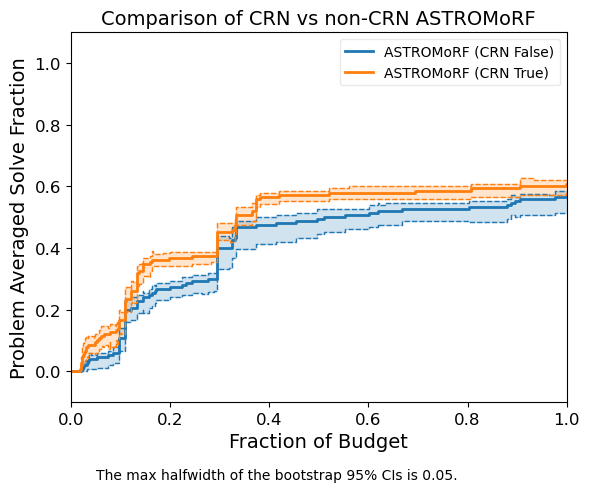

Plotting complete!


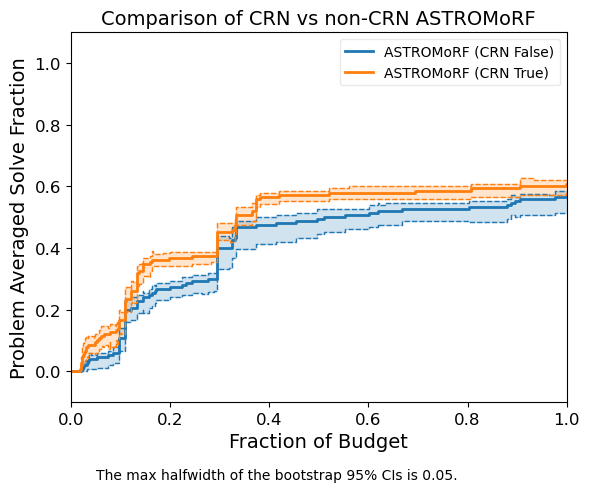

In [15]:


print("Plotting results...")

ps_same_problem_dict = {}
# take the experiments of comparison_experiment and create a list of lists from ps_same_problem_list where each sublist contains all solvers for a given problem
experiments_flattened = [ps for solver_experiments in crn_experiment.experiments for ps in solver_experiments]
for exp in experiments_flattened:
    if exp.problem.name not in ps_same_problem_dict:
        ps_same_problem_dict[exp.problem.name] = []
    ps_same_problem_dict[exp.problem.name].append(exp)

#turn the items of ps_same_problem_dict into a list of lists
experiments_flattened = []
for problem_name, ps_list in ps_same_problem_dict.items():
    experiments_flattened.append(ps_list)








def _print_path_and_display(plot_paths: list[Path]) -> None:
    for plot_path in plot_paths:
        print(f"Plot saved to {plot_path!s}")
        display(Image(filename=str(plot_path)))


_print_path_and_display(
    plot_solvability_profiles(
        experiments=crn_experiment.experiments, plot_type=PlotType.CDF_SOLVABILITY,
        plot_title=f"Comparison of CRN vs non-CRN ASTROMoRF",
        legend_loc="upper right",
    )
)


# for problem in experiments_flattened:
#     _print_path_and_display(
#         plot_progress_curves(
#             experiments=problem, 
#             plot_type=PlotType.MEAN, 
#             solver_set_name="ASTROMoRF CRN Comparison", 
#             normalize=True,
#             allow_xstar_mismatch=True,
            
#         )
#     )

# # comparison_experiment.experiments is structured as experiments[solver_idx][problem_idx]
# # To plot all solvers for each problem, we need to transpose the structure
# n_solvers = len(crn_experiment.experiments)
# n_problems = len(crn_experiment.experiments[0]) if n_solvers > 0 else 0

# for prob_idx in range(n_problems):
#     # Collect all solvers for this problem
#     solvers_for_problem = [crn_experiment.experiments[solver_idx][prob_idx] for solver_idx in range(n_solvers)]
#     #get the terminal budget for each problem solver 
#     [print(f"solver {s.solver.name} on problem {s.problem.name} has budget {[x[-1] for x in s.all_budget_history]}") for s in solvers_for_problem]


#     # Maybe move the y-axis to being logarithmic 
#     _print_path_and_display(
#         plot_fn_estimates(
#             experiments=solvers_for_problem,
#             plot_type=PlotType.FN_ESTIMATES_MEAN, 
#             solver_set_name="ASTROMoRF CRN Comparison", 
#             normalize=True,
#             all_in_one=False
#         )
#     )
#     _print_path_and_display(
#         plot_budget_history(
#             experiments=solvers_for_problem,
#             plot_type=PlotType.BUDGET_HISTORY_MEAN, 
#             solver_set_name="ASTROMoRF CRN Comparison", 
#             normalize=True
#         )
#     )

print("Plotting complete!")

## EXPERIMENT 3: Datafarming on Polynomial Basis Type and Subspace Dimension

This final experiment looks at how the polynomial basis type and initial subspace dimension affects the performance of ASTROMoRF

In [16]:
#load in the subspace datafarming experiments
path_datafarming_subspace = "/Users/benjaminrees/Desktop/Journal_Pickles/datafarming_experiments/Subspace"
pickles_datafarming_subspace = [f for f in os.listdir(path_datafarming_subspace) if f.endswith('.pickle') and "POSTREPS" in f]

#from the experiments_comparison, get the experiments with the solver.name "ASTROMoRF"
datafarming_experiments_subspace = []
#now load in the CRN experiments and append to the astromorf_experiments list
for pkl in pickles_datafarming_subspace:
    #only test on SAN-1 problems
    experiment = read_experiment_results(os.path.join(path_datafarming_subspace, pkl))
    datafarming_experiments_subspace.append(experiment) 

In [17]:
#load in the polybases datafarming experiments
path_datafarming_polybases = "/Users/benjaminrees/Desktop/Journal_Pickles/datafarming_experiments/PolynomialBases"
pickles_datafarming_polybases = [f for f in os.listdir(path_datafarming_polybases) if f.endswith('.pickle') and "POSTREPS" in f]

#from the experiments_comparison, get the experiments with the solver.name "ASTROMoRF"
datafarming_experiments_polybases = []
#now load in the CRN experiments and append to the astromorf_experiments list
for pkl in pickles_datafarming_polybases:
    experiment = read_experiment_results(os.path.join(path_datafarming_polybases, pkl))
    datafarming_experiments_polybases.append(experiment) 

In [18]:
experiments_sorted_datafarming_subspace = {}
for exp in datafarming_experiments_subspace:
    key = exp.solver.name
    if key not in experiments_sorted_datafarming_subspace:
        experiments_sorted_datafarming_subspace[key] = []
    experiments_sorted_datafarming_subspace[key].append(exp)

#now turn experiments_sorted into a list of lists where each value of the dict is a sublist 
ps_list_datafarming_subspace = list(experiments_sorted_datafarming_subspace.values())
file_name_path_subspace = experiment_dir / "datafarming_experiment_results_subspace.pickle"
datafarming_experiment_subspace = ProblemsSolvers(experiments=ps_list_datafarming_subspace, file_name_path=file_name_path_subspace)

In [19]:
#For all the dynamews experiments within datafarming_experiments_polybases
experiments_sorted_datafarming_polybases = {}

In [20]:
experiments_sorted_datafarming_polybases = {}
for exp in datafarming_experiments_polybases:
    key = exp.solver.name
    if key not in experiments_sorted_datafarming_polybases:
        experiments_sorted_datafarming_polybases[key] = []
    experiments_sorted_datafarming_polybases[key].append(exp)

#now turn experiments_sorted into a list of lists where each value of the dict is a sublist 
ps_list_datafarming_polybases = list(experiments_sorted_datafarming_polybases.values())
file_name_path_polybases = experiment_dir / "datafarming_experiment_results_polybases.pickle"
datafarming_experiment_polybases = ProblemsSolvers(experiments=ps_list_datafarming_polybases, file_name_path=file_name_path_polybases)

In [21]:
#get number of postreps from first experiment in the list
num_postreps_init_opt = datafarming_experiments_subspace[0].n_postreps

# Configure logging so we see which pair is currently running
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
print("Logging set to INFO. You will see per-pair progress as they start/finish.")

print("Post-normalizing results.")

datafarming_experiment_subspace.post_normalize(
    n_postreps_init_opt=num_postreps_init_opt,
)
# Record and log results
datafarming_experiment_subspace.record_group_experiment_results()
datafarming_experiment_subspace.log_group_experiment_results()
datafarming_experiment_subspace.report_group_statistics()

2026-02-18 17:35:03,113 | INFO | Postnormalizing on Problem NETWORK-1.
2026-02-18 17:35:03,304 | INFO | Global proxy x* computed for problem NETWORK-1.
2026-02-18 17:35:03,304 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.


Logging set to INFO. You will see per-pair progress as they start/finish.
Post-normalizing results.


2026-02-18 17:35:03,481 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-02-18 17:35:03,660 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-02-18 17:35:03,834 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-02-18 17:35:04,010 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-02-18 17:35:04,186 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-02-18 17:35:04,359 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-02-18 17:35:04,535 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-02-18 17:35:04,709 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-02-18 17:35:04,884 | INFO | Finding f(x*) using using global best postreplicated solution as proxy 

Figure saved to: /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-02-18_17-31-24/plots/performance_vs_subspace_dimension.png


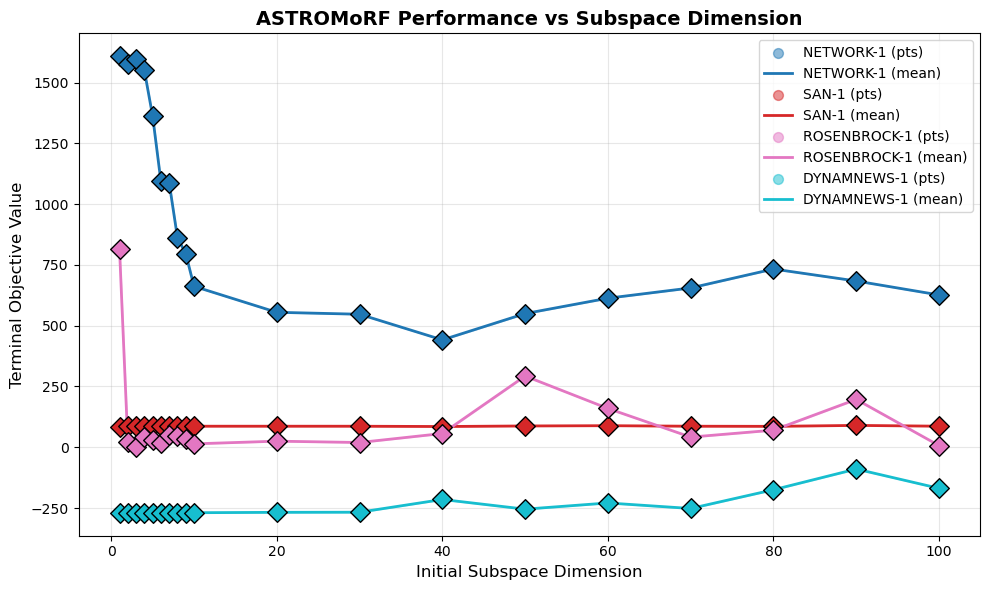

Figure saved to: /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-02-18_17-31-24/plots/fraction_closed_vs_subspace_dimension.png


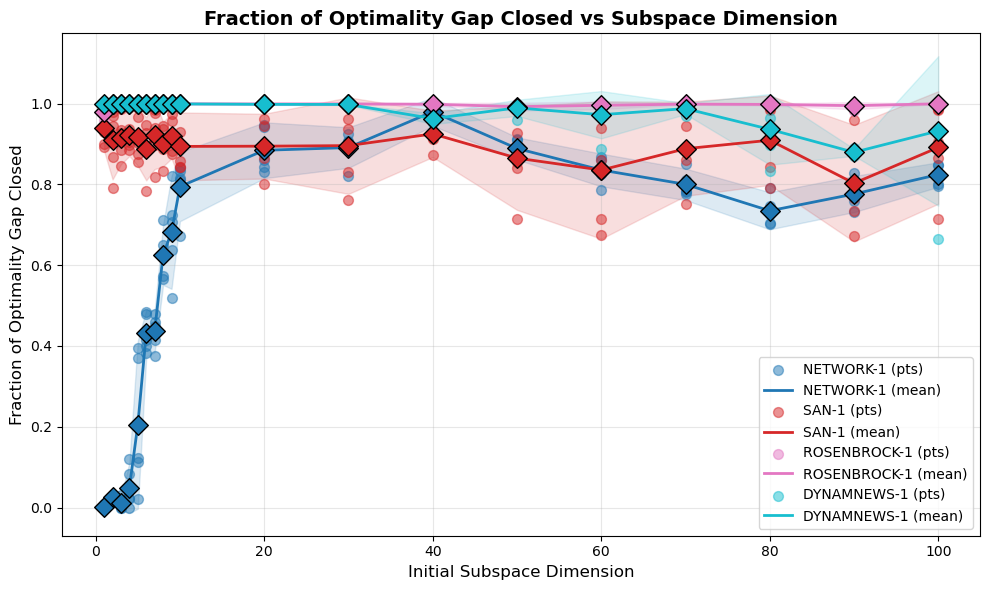

Figure saved to: /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-02-18_17-31-24/plots/convergence_rate_vs_subspace_dimension.png


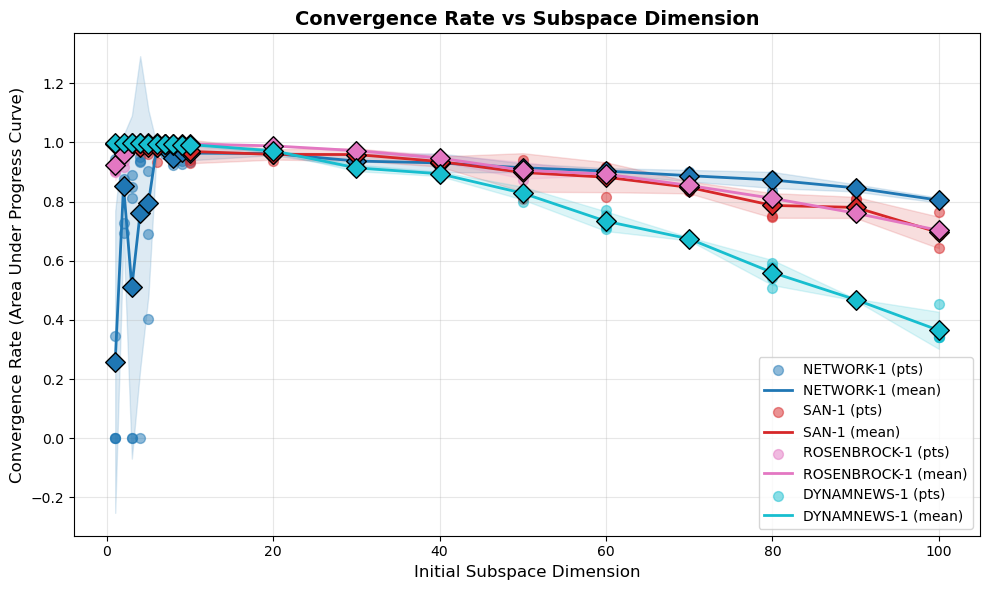

Figure saved to: /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-02-18_17-31-24/plots/budget_to_threshold_vs_subspace_dimension.png


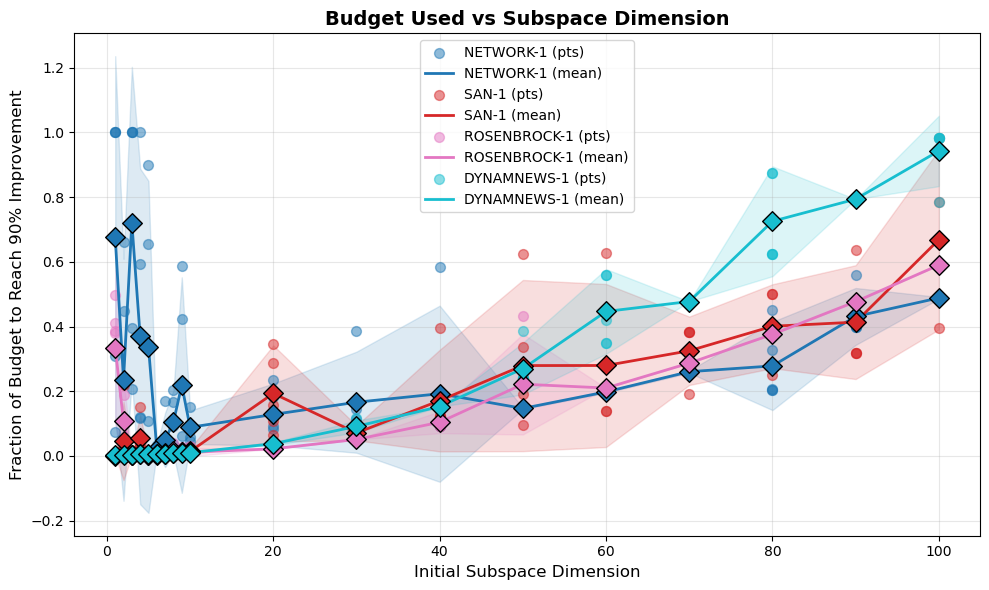

In [22]:
# Plot the data farming results

#Reload the module to get any recent changes
# import importlib
# import demo.plot_datafarming
# importlib.reload(demo.plot_datafarming)

# Plot terminal objective vs subspace dimension
fig, ax = plot_datafarming_results(
    experiments=datafarming_experiment_subspace,  # Pass the ProblemsSolvers object directly
    factor_name="initial subspace dimension",
    y_metric="terminal_objective",
    title="ASTROMoRF Performance vs Subspace Dimension",
    show_confidence_interval=True,
    save_path=SAVE_PATH / "performance_vs_subspace_dimension.png"
)

fig3, ax3 = plot_datafarming_results(
    experiments=datafarming_experiment_subspace,
    factor_name="initial subspace dimension", 
    y_metric="fraction_closed",
    title="Fraction of Optimality Gap Closed vs Subspace Dimension",
    save_path=SAVE_PATH / "fraction_closed_vs_subspace_dimension.png"
)

# Alternatively, plot the fraction of optimality gap closed
# fig2, ax2 = plot_datafarming_results(
#     experiments=datafarming_experiment_subspace,
#     factor_name="initial subspace dimension", 
#     y_metric="optimality_gap_fraction",
#     title="Fraction of Optimality Gap Closed vs Subspace Dimension",
# )

fig3, ax3 = plot_datafarming_results(
    experiments=datafarming_experiment_subspace,
    factor_name="initial subspace dimension", 
    y_metric="convergence_rate",
    convergence_method="area_ratio",
    title="Convergence Rate vs Subspace Dimension",
    save_path=SAVE_PATH / "convergence_rate_vs_subspace_dimension.png"
)


# fig3, ax3 = plot_datafarming_results(
#     experiments=datafarming_experiment_subspace,
#     factor_name="initial subspace dimension", 
#     y_metric="convergence_rate",
#     convergence_method="linear_fit",
#     title="Convergence Rate vs Subspace Dimension",
# )

fig3, ax3 = plot_datafarming_results(
    experiments=datafarming_experiment_subspace,
    factor_name="initial subspace dimension", 
    y_metric="convergence_rate",
    convergence_method="budget_to_threshold",
    title="Budget Used vs Subspace Dimension",
    save_path=SAVE_PATH / "budget_to_threshold_vs_subspace_dimension.png"
)

In [23]:
#get number of postreps from first experiment in the list
num_postreps_init_opt = datafarming_experiments_polybases[0].n_postreps

# Configure logging so we see which pair is currently running
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
print("Logging set to INFO. You will see per-pair progress as they start/finish.")

print("Post-normalizing results.")

datafarming_experiment_polybases.post_normalize(
    n_postreps_init_opt=num_postreps_init_opt,
)
# Record and log results
datafarming_experiment_polybases.record_group_experiment_results()
datafarming_experiment_polybases.log_group_experiment_results()
datafarming_experiment_polybases.report_group_statistics()

2026-02-18 17:35:12,236 | INFO | Postnormalizing on Problem NETWORK-1.


Logging set to INFO. You will see per-pair progress as they start/finish.
Post-normalizing results.


2026-02-18 17:35:12,415 | INFO | Global proxy x* computed for problem NETWORK-1.
2026-02-18 17:35:12,415 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-02-18 17:35:12,594 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-02-18 17:35:12,772 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-02-18 17:35:12,948 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-02-18 17:35:13,125 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-02-18 17:35:13,302 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-02-18 17:35:13,477 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-02-18 17:35:13,654 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-02-18 17:35:13,829

Figure saved to: /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-02-18_17-31-24/plots/performance_vs_polynomial_basis.png


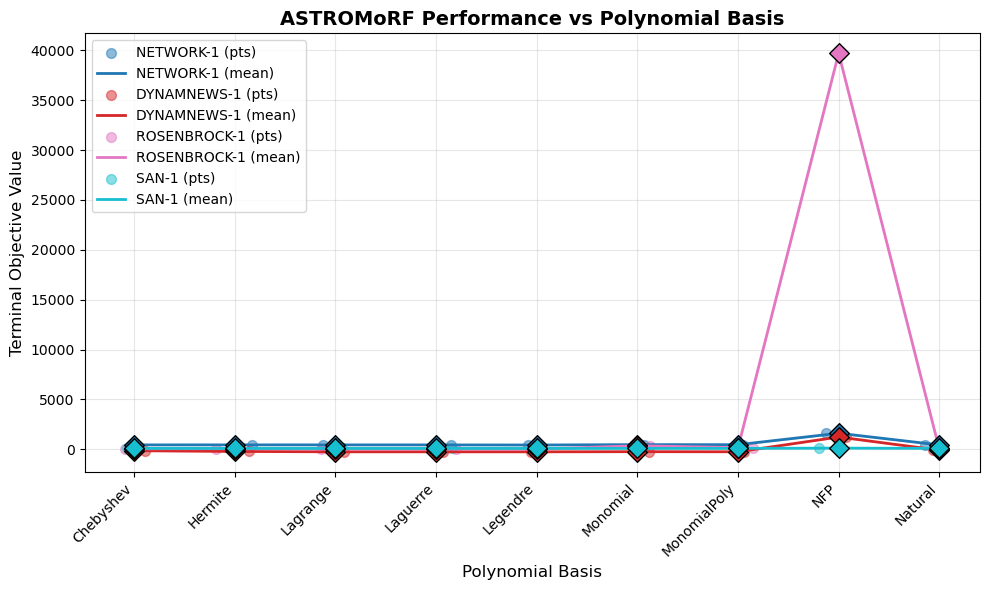

Figure saved to: /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-02-18_17-31-24/plots/fraction_closed_vs_polynomial_basis.png


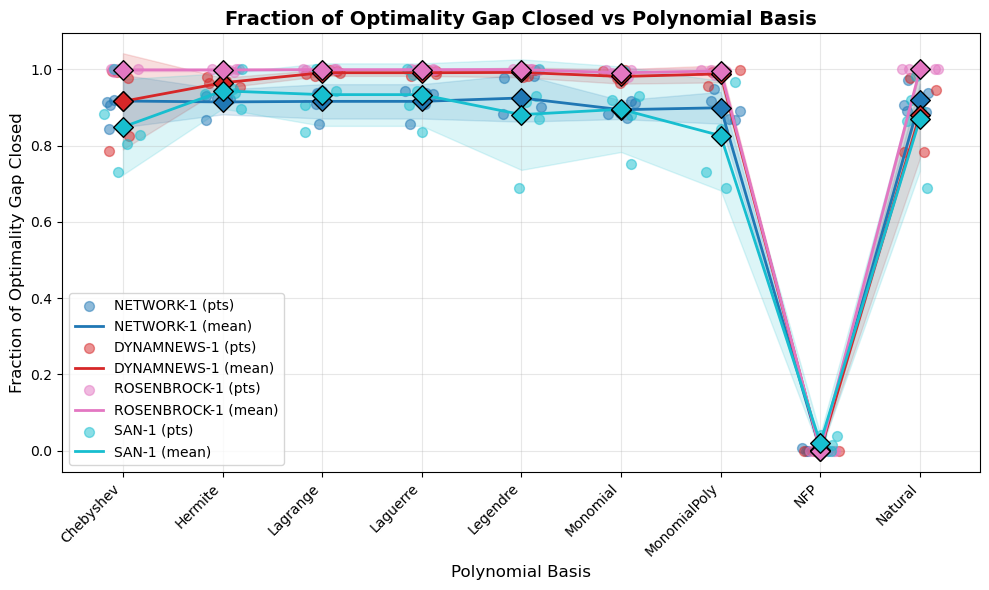

Figure saved to: /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-02-18_17-31-24/plots/convergence_rate_vs_polynomial_basis.png


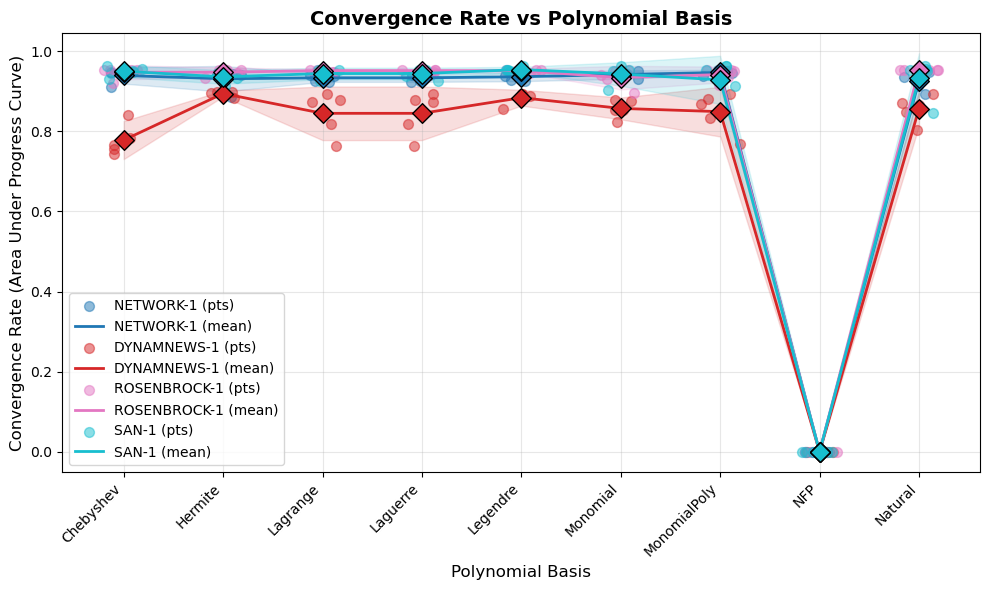

Figure saved to: /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-02-18_17-31-24/plots/budget_to_threshold_vs_polynomial_basis.png


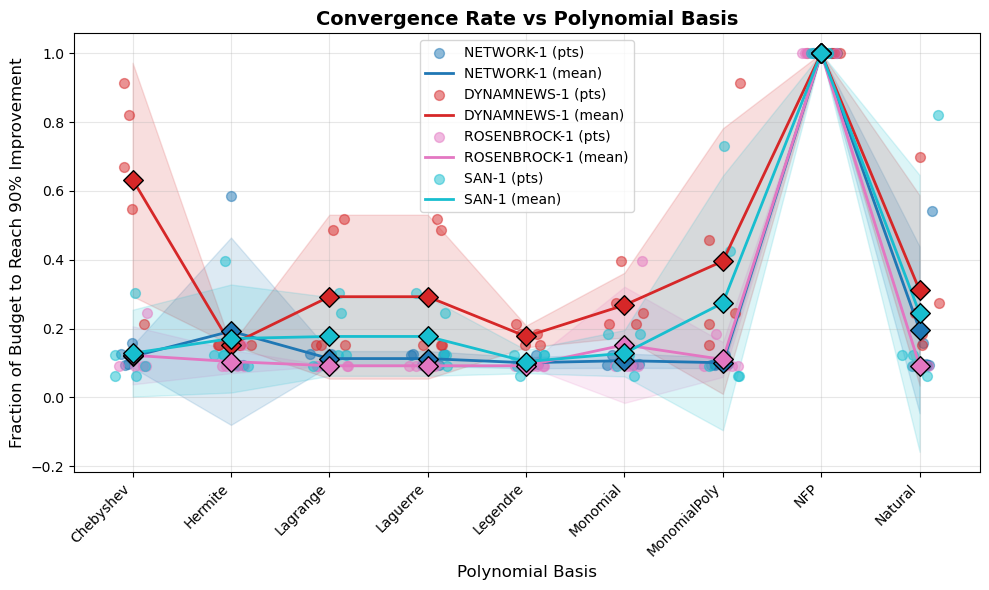

In [24]:
fig, ax = plot_datafarming_results(
    experiments=datafarming_experiment_polybases,  # Pass the ProblemsSolvers object directly
    factor_name="polynomial basis",
    y_metric="terminal_objective",
    title="ASTROMoRF Performance vs Polynomial Basis",
    show_confidence_interval=True,
    save_path=SAVE_PATH / "performance_vs_polynomial_basis.png"
)

# Alternatively, plot the fraction of optimality gap closed
fig2, ax2 = plot_datafarming_results(
    experiments=datafarming_experiment_polybases,
    factor_name="polynomial basis", 
    y_metric="fraction_closed",
    title="Fraction of Optimality Gap Closed vs Polynomial Basis",
    save_path=SAVE_PATH / "fraction_closed_vs_polynomial_basis.png"
)

fig3, ax3 = plot_datafarming_results(
    experiments=datafarming_experiment_polybases,
    factor_name="polynomial basis", 
    y_metric="convergence_rate",
    convergence_method="area_ratio",
    title="Convergence Rate vs Polynomial Basis",
    save_path=SAVE_PATH / "convergence_rate_vs_polynomial_basis.png"
)

# fig3, ax3 = plot_datafarming_results(
#     experiments=datafarming_experiment_polybases,
#     factor_name="polynomial basis", 
#     y_metric="convergence_rate",
#     convergence_method="linear_fit",
#     title="Convergence Rate vs Polynomial Basis",
# )

fig3, ax3 = plot_datafarming_results(
    experiments=datafarming_experiment_polybases,
    factor_name="polynomial basis", 
    y_metric="convergence_rate",
    convergence_method="budget_to_threshold",
    title="Convergence Rate vs Polynomial Basis",
    save_path=SAVE_PATH / "budget_to_threshold_vs_polynomial_basis.png"
)

In [25]:
# # Create a DataFrame for further analysis
# df = create_results_dataframe(
#     experiments=datafarming_experiment,
#     factor_names=["initial subspace dimension", "polynomial basis"],
# )


# print(df.head(10))